# Problem 3 - Noise impact on long-range CNOT

This notebook starts a clean Problem 3 implementation. It fixes the main issues in the combined `p2_and_3` notebook:

- `Ic` and `dynamic` are real CNOT circuits, not Bell-test circuits with `H(control)` baked into the gate.
- The primary metric is CNOT process fidelity `F_pro`, with average gate fidelity `F_avg = (4 F_pro + 1) / 5` reported as a derived value.
- Noisy exact simulation is guarded by a maximum qubit count so we do not accidentally run 50 to 100 qubit noisy Aer jobs.
- Noise channels follow the statement: depolarizing gate noise, readout error, and thermal relaxation (`T1/T2`).
- The paper-style error budget is computed from `t_idle`, `N_CNOT`, and `N_meas`.

Default cells below run only short smoke tests. Larger sweeps should be enabled explicitly after checking cost.


In [1]:
from __future__ import annotations

import math
import random
from dataclasses import asdict, dataclass
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import expr
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, thermal_relaxation_error

SEED = 1557
DEFAULT_SHOTS = 128
MAX_EXACT_NOISY_QUBITS = 12

random.seed(SEED)
np.random.seed(SEED)


def package_version(distribution_name: str, import_name: str | None = None) -> str:
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        if import_name is None:
            return "not installed"
        try:
            module = __import__(import_name)
            return getattr(module, "__version__", "not installed")
        except Exception:
            return "not installed"


version_rows = pd.DataFrame(
    [
        ("numpy", package_version("numpy")),
        ("pandas", package_version("pandas")),
        ("matplotlib", package_version("matplotlib")),
        ("qiskit", package_version("qiskit")),
        ("qiskit-aer", package_version("qiskit-aer", "qiskit_aer")),
        ("qiskit-ibm-runtime", package_version("qiskit-ibm-runtime", "qiskit_ibm_runtime")),
    ],
    columns=["package", "version"],
)
version_rows


,package,version
0,numpy,2.4.6
1,pandas,3.0.4
2,matplotlib,3.10.9
3,qiskit,2.4.1
4,qiskit-aer,0.17.2
5,qiskit-ibm-runtime,0.47.0


## Circuit builders

`distance` is the number of intermediate bus/ancilla qubits between control and target. The total qubit count is `distance + 2`.

The dynamic circuit follows the long-range CNOT teleportation construction. The unitary circuit is Strategy Ic from Appendix B, with `4n + 1` CNOT gates and zero idle-time term in the paper budget.


In [2]:
def validate_distance(distance: int) -> int:
    distance = int(distance)
    if distance < 0:
        raise ValueError("distance must be non-negative")
    return distance


def dynamic_x0(distance: int) -> int:
    return 1 if distance % 2 == 0 else 2


def build_dynamic_cnot(distance: int) -> QuantumCircuit:
    """Dynamic long-range CNOT via gate teleportation. No input-state preparation is included."""
    n = validate_distance(distance)
    k = n // 2

    control = QuantumRegister(1, "control")
    anc = QuantumRegister(n, "anc") if n else QuantumRegister(0, "anc")
    target = QuantumRegister(1, "target")
    cr = ClassicalRegister(2, "cr")

    cregs = [cr]
    if n > 1:
        cregs.append(ClassicalRegister(k, "c_zz"))
    if n > 0:
        cregs.append(ClassicalRegister(n - k, "c_xx"))

    qc = QuantumCircuit(control, anc, target, *cregs, name=f"dynamic_cnot_n{n}")
    q = [control[0], *list(anc), target[0]]
    x0 = dynamic_x0(n)

    if n % 2 != 0:
        qc.cx(q[0], q[1])

    for i in range(k):
        qc.h(q[x0 + 2 * i])
        qc.cx(q[x0 + 2 * i], q[x0 + 2 * i + 1])

    for i in range(k + 1):
        qc.cx(q[x0 - 1 + 2 * i], q[x0 + 2 * i])

    for i in range(1, k + x0):
        qc.h(q[2 * i + 1 - x0])

    if n > 1:
        c_zz = qc.cregs[1]
        for i in range(k):
            qc.measure(q[2 * i + x0], c_zz[i])

    if n > 0:
        c_xx = qc.cregs[-1]
        for i in range(1, k + x0):
            qc.measure(q[2 * i + 1 - x0], c_xx[i - 1])

    if n > 0:
        c_xx = qc.cregs[-1]
        parity_xx = expr.lift(c_xx[0])
        for i in range(2, k + x0):
            parity_xx = expr.bit_xor(c_xx[i - 1], parity_xx)
        with qc.if_test(parity_xx):
            qc.z(q[0])

    if n > 1:
        c_zz = qc.cregs[1]
        parity_zz = expr.lift(c_zz[0])
        for i in range(1, k):
            parity_zz = expr.bit_xor(c_zz[i], parity_zz)
        with qc.if_test(parity_zz):
            qc.x(q[-1])

    qc.metadata = {
        "implementation": "dynamic",
        "distance": n,
        "control_index": 0,
        "target_index": n + 1,
    }
    return qc


def build_unitary_cnot_ic(distance: int) -> QuantumCircuit:
    """Strategy Ic unitary long-range CNOT from Appendix B. No input-state preparation is included."""
    n = validate_distance(distance)
    control = QuantumRegister(1, "control")
    anc = QuantumRegister(n, "anc") if n else QuantumRegister(0, "anc")
    target = QuantumRegister(1, "target")
    cr = ClassicalRegister(2, "cr")
    qc = QuantumCircuit(control, anc, target, cr, name=f"unitary_Ic_n{n}")

    q = [control[0], *list(anc), target[0]]
    num_qubits = len(q)
    k = n // 2

    for i in range(k):
        qc.cx(q[i], q[i + 1])
        qc.cx(q[i + 1], q[i])
        qc.cx(q[num_qubits - 1 - i], q[num_qubits - 2 - i])
        qc.cx(q[num_qubits - 2 - i], q[num_qubits - 1 - i])

    if n % 2 == 1:
        qc.cx(q[k + 2], q[k + 1])
        qc.cx(q[k + 1], q[k + 2])

    qc.cx(q[k], q[k + 1])

    for i in range(k):
        qc.cx(q[k - i], q[k - 1 - i])
        qc.cx(q[k - 1 - i], q[k - i])
        qc.cx(q[k + i + 1], q[k + i + 2])
        qc.cx(q[k + i + 2], q[k + i + 1])

    if n % 2 == 1:
        qc.cx(q[num_qubits - 2], q[num_qubits - 1])
        qc.cx(q[num_qubits - 1], q[num_qubits - 2])

    qc.metadata = {
        "implementation": "unitary_Ic",
        "distance": n,
        "control_index": 0,
        "target_index": n + 1,
    }
    return qc


CNOT_BUILDERS = {
    "dynamic": build_dynamic_cnot,
    "unitary_Ic": build_unitary_cnot_ic,
}


def build_cnot_circuit(implementation: str, distance: int) -> QuantumCircuit:
    if implementation not in CNOT_BUILDERS:
        raise ValueError(f"implementation must be one of {sorted(CNOT_BUILDERS)}")
    return CNOT_BUILDERS[implementation](distance)


def count_2q_gates(qc: QuantumCircuit) -> int:
    return sum(1 for item in qc.data if item.operation.num_qubits == 2)


def circuit_summary(qc: QuantumCircuit) -> dict:
    ops = qc.count_ops()
    return {
        "name": qc.name,
        "num_qubits": qc.num_qubits,
        "depth": qc.depth(),
        "depth_2q": qc.depth(lambda inst: inst.operation.num_qubits == 2),
        "N_CNOT": int(ops.get("cx", 0)),
        "N_meas": int(ops.get("measure", 0)),
        "N_if_else": int(ops.get("if_else", 0)),
    }


pd.DataFrame([circuit_summary(build_cnot_circuit(impl, distance=4)) for impl in CNOT_BUILDERS])


,name,num_qubits,depth,depth_2q,N_CNOT,N_meas,N_if_else
0,dynamic_cnot_n4,6,6,2,5,4,2
1,unitary_Ic_n4,6,9,9,17,0,0


## CNOT process fidelity

The runner below uses the 16 Pauli terms for CNOT process certification. The identity-output term is known exactly, so the simulator executes 15 terms times 4 input eigenstate preparations.


In [3]:
CNOT_PROCESS_PAULI_TERMS = [
    {"term": "IIII", "ideal": 1},
    {"term": "IXIX", "ideal": 1},
    {"term": "IYZY", "ideal": 1},
    {"term": "IZZZ", "ideal": 1},
    {"term": "XIXX", "ideal": 1},
    {"term": "XXXI", "ideal": 1},
    {"term": "XYYZ", "ideal": 1},
    {"term": "XZYY", "ideal": -1},
    {"term": "YIYX", "ideal": 1},
    {"term": "YXYI", "ideal": 1},
    {"term": "YYXZ", "ideal": -1},
    {"term": "YZXY", "ideal": 1},
    {"term": "ZIZI", "ideal": 1},
    {"term": "ZXZX", "ideal": 1},
    {"term": "ZYIY", "ideal": 1},
    {"term": "ZZIZ", "ideal": 1},
]


def local_pauli_prep_options(pauli: str) -> list[dict]:
    if pauli == "I":
        return [{"label": "0", "eigenvalue": 1}, {"label": "1", "eigenvalue": 1}]
    if pauli in {"X", "Y", "Z"}:
        return [{"label": "+", "eigenvalue": 1}, {"label": "-", "eigenvalue": -1}]
    raise ValueError(f"Unsupported Pauli {pauli!r}.")


def prepare_local_pauli_eigenstate(qc: QuantumCircuit, qubit, pauli: str, option: dict) -> None:
    label = option["label"]
    eigenvalue = int(option["eigenvalue"])
    if pauli == "I":
        if label == "1":
            qc.x(qubit)
        return
    if pauli == "Z":
        if eigenvalue == -1:
            qc.x(qubit)
        return
    if eigenvalue == -1:
        qc.x(qubit)
    qc.h(qubit)
    if pauli == "Y":
        qc.s(qubit)


def measure_local_pauli(qc: QuantumCircuit, qubit, pauli: str, clbit) -> None:
    if pauli == "I":
        return
    if pauli == "X":
        qc.h(qubit)
    elif pauli == "Y":
        qc.sdg(qubit)
        qc.h(qubit)
    elif pauli != "Z":
        raise ValueError(f"Unsupported Pauli {pauli!r}.")
    qc.measure(qubit, clbit)


def compose_base_cnot_circuit(process_circuit: QuantumCircuit, base_circuit: QuantumCircuit) -> None:
    qubits = list(range(base_circuit.num_qubits))
    if base_circuit.num_clbits:
        process_circuit.compose(
            base_circuit,
            qubits=qubits,
            clbits=list(range(base_circuit.num_clbits)),
            inplace=True,
        )
    else:
        process_circuit.compose(base_circuit, qubits=qubits, inplace=True)


def build_cnot_process_circuits(circuit: QuantumCircuit) -> dict:
    if circuit.num_qubits < 2:
        raise ValueError("CNOT process certification requires at least two circuit qubits.")

    control = int((circuit.metadata or {}).get("control_index", 0))
    target = int((circuit.metadata or {}).get("target_index", circuit.num_qubits - 1))

    process_terms = []
    process_specs = []
    process_circuits = []

    for term_info in CNOT_PROCESS_PAULI_TERMS:
        term = term_info["term"]
        ideal = int(term_info["ideal"])
        input_pauli = term[:2]
        output_pauli = term[2:]
        process_terms.append(
            {"term": term, "ideal": ideal, "input_pauli": input_pauli, "output_pauli": output_pauli, "executed": output_pauli != "II"}
        )
        if output_pauli == "II":
            continue

        for control_option in local_pauli_prep_options(input_pauli[0]):
            for target_option in local_pauli_prep_options(input_pauli[1]):
                qc = QuantumCircuit(circuit.num_qubits, circuit.num_clbits, name=f"proc_{term}")
                prepare_local_pauli_eigenstate(qc, control, input_pauli[0], control_option)
                prepare_local_pauli_eigenstate(qc, target, input_pauli[1], target_option)
                compose_base_cnot_circuit(qc, circuit)

                measured_qubits = [q for q, p in ((control, output_pauli[0]), (target, output_pauli[1])) if p != "I"]
                process_register = ClassicalRegister(len(measured_qubits), "proc")
                qc.add_register(process_register)

                measured_clbits = []
                measured_register_bits = []
                next_clbit = 0
                for qubit, pauli in ((control, output_pauli[0]), (target, output_pauli[1])):
                    if pauli == "I":
                        continue
                    measure_local_pauli(qc, qubit, pauli, process_register[next_clbit])
                    measured_clbits.append(qc.find_bit(process_register[next_clbit]).index)
                    measured_register_bits.append(next_clbit)
                    next_clbit += 1

                prep_weight = int(control_option["eigenvalue"] * target_option["eigenvalue"])
                spec = {
                    "term": term,
                    "ideal": ideal,
                    "input_pauli": input_pauli,
                    "output_pauli": output_pauli,
                    "control_prep": dict(control_option),
                    "target_prep": dict(target_option),
                    "prep_weight": prep_weight,
                    "prep_average_weight": 0.25,
                    "measured_clbits": measured_clbits,
                    "num_clbits": qc.num_clbits,
                    "measurement_register": "proc",
                    "measured_register_bits": measured_register_bits,
                    "measurement_register_size": len(process_register),
                    "circuit_index": len(process_circuits),
                }
                qc.metadata = dict(circuit.metadata or {})
                qc.metadata.update({"process_certification": spec})
                process_specs.append(spec)
                process_circuits.append(qc)

    return {"terms": process_terms, "specs": process_specs, "circuits": process_circuits}


def counts_total_shots(counts: dict) -> int:
    return int(sum(int(value) for value in counts.values())) if counts else 0


def count_key_to_bits(count_key, total_clbits: int = 0) -> str:
    clean = str(count_key).replace(" ", "")
    if clean.startswith("0x"):
        bits = bin(int(clean, 16))[2:]
    else:
        bits = "".join(char for char in clean if char in "01")
    if total_clbits:
        bits = bits.zfill(total_clbits)
    return bits


def counts_pauli_expectation(counts: dict, measured_clbits: list[int] | tuple[int, ...], total_clbits: int) -> float | None:
    if not measured_clbits:
        return 1.0
    shots = counts_total_shots(counts)
    if shots == 0:
        return None

    total = 0.0
    for count_key, count in counts.items():
        bits = count_key_to_bits(count_key, total_clbits)
        eigenvalue = 1
        for clbit in measured_clbits:
            bit = bits[-1 - clbit] if clbit < len(bits) else "0"
            eigenvalue *= -1 if bit == "1" else 1
        total += eigenvalue * int(count)
    return total / shots


def calculate_cnot_process_fidelity(process_specs: list[dict], counts_list: list[dict] | None, process_terms: list[dict] | None = None) -> dict | None:
    if counts_list is None:
        return None

    process_terms = process_terms or CNOT_PROCESS_PAULI_TERMS
    term_estimates = {"IIII": 1.0}
    term_shots = {"IIII": None}
    partial_sums = {}
    partial_shots = {}

    for spec, counts in zip(process_specs, counts_list):
        if counts is None:
            return None
        expectation = counts_pauli_expectation(counts, spec["measured_clbits"], spec["num_clbits"])
        if expectation is None:
            return None

        term = spec["term"]
        partial_sums[term] = partial_sums.get(term, 0.0) + spec["prep_average_weight"] * spec["prep_weight"] * expectation
        partial_shots[term] = partial_shots.get(term, 0) + counts_total_shots(counts)

    for term, estimate in partial_sums.items():
        term_estimates[term] = estimate
        term_shots[term] = partial_shots.get(term)

    rows = []
    process_sum = 0.0
    for term_info in process_terms:
        term = term_info["term"]
        ideal = int(term_info["ideal"])
        estimate = term_estimates.get(term)
        if estimate is None:
            return None
        contribution = ideal * estimate / 16.0
        process_sum += contribution
        rows.append({"term": term, "ideal": ideal, "estimate": estimate, "ideal_times_estimate": ideal * estimate, "process_contribution": contribution, "shots": term_shots.get(term)})

    return {"process_fidelity": process_sum, "average_gate_fidelity": (4.0 * process_sum + 1.0) / 5.0, "term_rows": rows}


base = build_cnot_circuit("dynamic", distance=2)
suite = build_cnot_process_circuits(base)
print(f"process circuits: {len(suite['circuits'])}; process terms: {len(suite['terms'])}")


process circuits: 60; process terms: 16


## Statement-style noise models

The statement asks us to compare depolarizing noise, readout error, and thermal relaxation. These models are intentionally simple and backend-independent at first. Later we can replace the constants with calibration values from a chosen fake or real backend.


In [4]:
@dataclass(frozen=True)
class NoiseConfig:
    name: str
    p_1q: float = 0.001
    p_cnot: float = 0.01
    p_readout: float = 0.02
    t1: float = 100e-6
    t2: float = 80e-6
    t_1q: float = 35e-9
    t_cnot: float = 300e-9
    t_measure: float = 1.0e-6
    include_depolarizing: bool = False
    include_readout: bool = False
    include_thermal: bool = False


def compose_quantum_errors(errors):
    errors = [err for err in errors if err is not None]
    if not errors:
        return None
    combined = errors[0]
    for err in errors[1:]:
        combined = combined.compose(err)
    return combined


def build_statement_noise_model(config: NoiseConfig) -> NoiseModel | None:
    if not (config.include_depolarizing or config.include_readout or config.include_thermal):
        return None

    if config.t1 <= 0 or config.t2 <= 0:
        raise ValueError("T1 and T2 must be positive.")
    t2 = min(config.t2, 2.0 * config.t1)
    noise_model = NoiseModel()

    one_qubit_errors = []
    two_qubit_errors = []
    if config.include_depolarizing:
        one_qubit_errors.append(depolarizing_error(config.p_1q, 1))
        two_qubit_errors.append(depolarizing_error(config.p_cnot, 2))
    if config.include_thermal:
        thermal_1q = thermal_relaxation_error(config.t1, t2, config.t_1q)
        thermal_2q = thermal_relaxation_error(config.t1, t2, config.t_cnot).tensor(thermal_relaxation_error(config.t1, t2, config.t_cnot))
        one_qubit_errors.append(thermal_1q)
        two_qubit_errors.append(thermal_2q)

    one_qubit_error = compose_quantum_errors(one_qubit_errors)
    if one_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(one_qubit_error, ["x", "sx", "h"])

    two_qubit_error = compose_quantum_errors(two_qubit_errors)
    if two_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(two_qubit_error, ["cx"])

    if config.include_readout:
        p = min(max(float(config.p_readout), 0.0), 1.0)
        noise_model.add_all_qubit_readout_error(ReadoutError([[1.0 - p, p], [p, 1.0 - p]]))

    return noise_model


NOISE_CONFIGS = {
    "ideal": NoiseConfig("ideal"),
    "depolarizing": NoiseConfig("depolarizing", include_depolarizing=True),
    "readout": NoiseConfig("readout", include_readout=True),
    "thermal": NoiseConfig("thermal", include_thermal=True),
    "combined": NoiseConfig("combined", include_depolarizing=True, include_readout=True, include_thermal=True),
}

pd.DataFrame([asdict(cfg) for cfg in NOISE_CONFIGS.values()])


,name,p_1q,p_cnot,p_readout,t1,t2,t_1q,t_cnot,t_measure,include_depolarizing,include_readout,include_thermal
0,ideal,0.001,0.01,0.02,0.0001,0.00008,3.500000e-08,3.000000e-07,0.000001,False,False,False
1,depolarizing,0.001,0.01,0.02,0.0001,0.00008,3.500000e-08,3.000000e-07,0.000001,True,False,False
2,readout,0.001,0.01,0.02,0.0001,0.00008,3.500000e-08,3.000000e-07,0.000001,False,True,False
3,thermal,0.001,0.01,0.02,0.0001,0.00008,3.500000e-08,3.000000e-07,0.000001,False,False,True
4,combined,0.001,0.01,0.02,0.0001,0.00008,3.500000e-08,3.000000e-07,0.000001,True,True,True


## Resource and error-budget helpers

The budget used in the statement is

`lambda_tot = t_idle * lambda_idle + N_CNOT * lambda_CNOT + N_meas * lambda_meas`.

For the dynamic protocol we use the paper-style idle-time expression `t_idle = 2 * mu + 2`, where `mu` is feed-forward latency in CNOT-time units. For Strategy Ic, Appendix B gives `t_idle = 0`.

Important: `N_meas` below means protocol mid-circuit measurements from the CNOT implementation. Aer readout noise is applied to every measurement operation, including the final process-certification measurements that are not part of the gate itself. The runner therefore also reports the average total number of measurements per process circuit as `N_process_meas_mean`.


In [5]:
def dynamic_idle_time_cnot_units(feedback_latency_cnot_units: float | None = 1.0) -> float | None:
    if feedback_latency_cnot_units is None:
        return None
    return 2.0 * float(feedback_latency_cnot_units) + 2.0


def implementation_resources(implementation: str, distance: int, feedback_latency_cnot_units: float | None = 1.0) -> dict:
    qc = build_cnot_circuit(implementation, distance)
    ops = qc.count_ops()
    if implementation == "dynamic":
        t_idle = dynamic_idle_time_cnot_units(feedback_latency_cnot_units)
    elif implementation == "unitary_Ic":
        t_idle = 0.0
    else:
        raise ValueError(implementation)

    return {
        "implementation": implementation,
        "distance": validate_distance(distance),
        "num_qubits": qc.num_qubits,
        "t_idle_cnot_units": t_idle,
        "N_CNOT": int(ops.get("cx", 0)),
        "N_meas": int(ops.get("measure", 0)),
        "N_mid_meas": int(ops.get("measure", 0)),
        "depth_2q": qc.depth(lambda inst: inst.operation.num_qubits == 2),
    }


def lambda_rates_from_noise(config: NoiseConfig) -> dict:
    t2 = min(config.t2, 2.0 * config.t1)
    lambda_idle = 1.0 - math.exp(-config.t_cnot / t2)
    return {
        "lambda_idle": lambda_idle if config.include_thermal else 0.0,
        "lambda_CNOT": config.p_cnot if config.include_depolarizing else 0.0,
        "lambda_meas": config.p_readout if config.include_readout else 0.0,
    }


def lambda_tot(resources: dict, rates: dict) -> float | None:
    t_idle = resources.get("t_idle_cnot_units")
    if t_idle is None:
        return None
    return float(t_idle) * rates["lambda_idle"] + float(resources["N_CNOT"]) * rates["lambda_CNOT"] + float(resources["N_meas"]) * rates["lambda_meas"]


def budget_row(implementation: str, distance: int, noise_config: NoiseConfig, feedback_latency_cnot_units: float = 1.0) -> dict:
    resources = implementation_resources(implementation, distance, feedback_latency_cnot_units)
    rates = lambda_rates_from_noise(noise_config)
    return {**resources, **rates, "noise_model": noise_config.name, "lambda_tot": lambda_tot(resources, rates)}


pd.DataFrame([budget_row(impl, 4, NOISE_CONFIGS["combined"]) for impl in ["dynamic", "unitary_Ic"]])


,implementation,distance,num_qubits,t_idle_cnot_units,N_CNOT,N_meas,N_mid_meas,depth_2q,lambda_idle,lambda_CNOT,lambda_meas,noise_model,lambda_tot
0,dynamic,4,6,4.0,5,4,4,2,0.003743,0.01,0.02,combined,0.144972
1,unitary_Ic,4,6,0.0,17,0,0,9,0.003743,0.01,0.02,combined,0.170000


## Runner

`run_cnot_process_fidelity` executes the 16-term CNOT process-certification circuits. By default, it refuses exact noisy simulation above `MAX_EXACT_NOISY_QUBITS`. This is deliberate: large-distance Problem 3 plots should use small exact simulations plus the analytical budget, not hidden 100-qubit noisy Aer jobs.


In [6]:
def make_simulator(noise_config: NoiseConfig, seed: int = SEED) -> AerSimulator:
    noise_model = build_statement_noise_model(noise_config)
    if noise_model is None:
        return AerSimulator(seed_simulator=seed)
    return AerSimulator(noise_model=noise_model, seed_simulator=seed)


PROCESS_SUITE_CACHE = {}


def prepare_process_suite(
    implementation: str,
    distance: int,
    seed: int = SEED,
    optimization_level: int = 0,
) -> dict:
    """Build and transpile the 60 process-certification circuits once per implementation/distance."""
    key = (implementation, validate_distance(distance), seed, optimization_level)
    if key in PROCESS_SUITE_CACHE:
        return PROCESS_SUITE_CACHE[key]

    base_circuit = build_cnot_circuit(implementation, distance)
    process_suite = build_cnot_process_circuits(base_circuit)
    reference_simulator = AerSimulator(seed_simulator=seed)
    isa_circuits = transpile(
        process_suite["circuits"],
        reference_simulator,
        optimization_level=optimization_level,
        seed_transpiler=seed,
    )
    process_measure_counts = [int(circuit.count_ops().get("measure", 0)) for circuit in process_suite["circuits"]]
    resources = implementation_resources(implementation, distance)

    prepared = {
        "implementation": implementation,
        "distance": validate_distance(distance),
        "base_circuit": base_circuit,
        "process_suite": process_suite,
        "isa_circuits": isa_circuits,
        "process_measure_counts": process_measure_counts,
        "resources": resources,
    }
    PROCESS_SUITE_CACHE[key] = prepared
    return prepared


def run_prepared_process_fidelity(
    prepared: dict,
    noise_config: NoiseConfig = NOISE_CONFIGS["ideal"],
    shots: int = DEFAULT_SHOTS,
    seed: int = SEED,
) -> dict:
    simulator = make_simulator(noise_config, seed=seed)
    isa_circuits = prepared["isa_circuits"]
    process_suite = prepared["process_suite"]
    result = simulator.run(isa_circuits, shots=shots, seed_simulator=seed).result()
    counts_list = [result.get_counts(i) for i in range(len(isa_circuits))]
    fidelity = calculate_cnot_process_fidelity(
        process_suite["specs"],
        counts_list,
        process_terms=process_suite["terms"],
    )
    resources = prepared["resources"]
    rates = lambda_rates_from_noise(noise_config)

    return {
        "implementation": prepared["implementation"],
        "distance": prepared["distance"],
        "num_qubits": prepared["base_circuit"].num_qubits,
        "noise_model": noise_config.name,
        "shots_per_circuit": int(shots),
        "num_process_circuits": len(isa_circuits),
        "process_fidelity": fidelity["process_fidelity"],
        "average_gate_fidelity": fidelity["average_gate_fidelity"],
        "lambda_tot": lambda_tot(resources, rates),
        "N_process_meas_mean": float(np.mean(prepared["process_measure_counts"])) if prepared["process_measure_counts"] else 0.0,
        **{k: resources[k] for k in ["t_idle_cnot_units", "N_CNOT", "N_meas", "N_mid_meas", "depth_2q"]},
    }


def run_cnot_process_fidelity(
    implementation: str,
    distance: int,
    noise_config: NoiseConfig = NOISE_CONFIGS["ideal"],
    shots: int = DEFAULT_SHOTS,
    seed: int = SEED,
    max_exact_noisy_qubits: int | None = MAX_EXACT_NOISY_QUBITS,
    optimization_level: int = 0,
) -> dict:
    base_circuit = build_cnot_circuit(implementation, distance)
    if max_exact_noisy_qubits is not None and base_circuit.num_qubits > max_exact_noisy_qubits:
        raise ValueError(
            f"Refusing exact noisy simulation for {base_circuit.num_qubits} qubits. "
            f"Set max_exact_noisy_qubits=None only after confirming the run cost."
        )
    prepared = prepare_process_suite(implementation, distance, seed=seed, optimization_level=optimization_level)
    return run_prepared_process_fidelity(prepared, noise_config=noise_config, shots=shots, seed=seed)


def run_process_grid(
    distances: list[int],
    implementations: list[str],
    noise_labels: list[str],
    shots: int = DEFAULT_SHOTS,
    max_exact_noisy_qubits: int | None = MAX_EXACT_NOISY_QUBITS,
) -> pd.DataFrame:
    rows = []
    for distance in distances:
        for implementation in implementations:
            prepared = prepare_process_suite(implementation, distance)
            if max_exact_noisy_qubits is not None and prepared["base_circuit"].num_qubits > max_exact_noisy_qubits:
                raise ValueError(
                    f"Refusing exact noisy simulation for {prepared['base_circuit'].num_qubits} qubits. "
                    f"Set max_exact_noisy_qubits=None only after confirming the run cost."
                )
            for noise_label in noise_labels:
                row = run_prepared_process_fidelity(
                    prepared,
                    noise_config=NOISE_CONFIGS[noise_label],
                    shots=shots,
                )
                rows.append(row)
                print(
                    f"n={distance:2d} {implementation:10s} {noise_label:13s} "
                    f"F_pro={row['process_fidelity']:.3f} F_avg={row['average_gate_fidelity']:.3f} "
                    f"lambda_tot={row['lambda_tot']:.4f}"
                )
    return pd.DataFrame(rows)


## Longer smoke sweep

This validates more than the trivial `n=0,2` cases while staying inside the exact noisy-simulation guard. The default sweep reaches `distance = 10` (`12` qubits) for both `Ic` and dynamic circuits.


In [7]:
RUN_SMOKE_TEST = True

if RUN_SMOKE_TEST:
    smoke_df = run_process_grid(
        distances=[0, 2, 4, 6, 8, 10],
        implementations=["unitary_Ic", "dynamic"],
        noise_labels=["ideal", "readout", "combined"],
        shots=64,
    )
else:
    smoke_df = pd.DataFrame()

smoke_df


n= 0 unitary_Ic ideal         F_pro=1.000 F_avg=1.000 lambda_tot=0.0000
n= 0 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 0 unitary_Ic combined      F_pro=0.932 F_avg=0.945 lambda_tot=0.0100


n= 0 dynamic    ideal         F_pro=1.000 F_avg=1.000 lambda_tot=0.0000
n= 0 dynamic    readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 0 dynamic    combined      F_pro=0.932 F_avg=0.945 lambda_tot=0.0250


n= 2 unitary_Ic ideal         F_pro=1.000 F_avg=1.000 lambda_tot=0.0000
n= 2 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 2 unitary_Ic combined      F_pro=0.847 F_avg=0.877 lambda_tot=0.0900


n= 2 dynamic    ideal         F_pro=1.000 F_avg=1.000 lambda_tot=0.0000
n= 2 dynamic    readout       F_pro=0.911 F_avg=0.929 lambda_tot=0.0400


n= 2 dynamic    combined      F_pro=0.877 F_avg=0.902 lambda_tot=0.0850


...

n=10 unitary_Ic combined      F_pro=0.592 F_avg=0.673 lambda_tot=0.4100


n=10 dynamic    ideal         F_pro=1.000 F_avg=1.000 lambda_tot=0.0000


n=10 dynamic    readout       F_pro=0.775 F_avg=0.820 lambda_tot=0.2000


n=10 dynamic    combined      F_pro=0.674 F_avg=0.739 lambda_tot=0.3250


,implementation,distance,num_qubits,noise_model,shots_per_circuit,num_process_circuits,process_fidelity,average_gate_fidelity,lambda_tot,N_process_meas_mean,t_idle_cnot_units,N_CNOT,N_meas,N_mid_meas,depth_2q
0,unitary_Ic,0,2,ideal,64,60,1.000000,1.000000,0.000000,1.6,0.0,1,0,0,1
1,unitary_Ic,0,2,readout,64,60,0.949219,0.959375,0.000000,1.6,0.0,1,0,0,1
2,unitary_Ic,0,2,combined,64,60,0.931641,0.945312,0.010000,1.6,0.0,1,0,0,1
3,dynamic,0,2,ideal,64,60,1.000000,1.000000,0.000000,1.6,4.0,1,0,0,1
4,dynamic,0,2,readout,64,60,0.949219,0.959375,0.000000,1.6,4.0,1,0,0,1
5,dynamic,0,2,combined,64,60,0.931641,0.945312,0.024972,1.6,4.0,1,0,0,1
6,unitary_Ic,2,4,ideal,64,60,1.000000,1.000000,0.000000,1.6,0.0,9,0,0,5
7,unitary_Ic,2,4,readout,64,60,0.949219,0.959375,0.000000,1.6,0.0,9,0,0,5
8,unitary_Ic,2,4,combined,64,60,0.846680,0.877344,0.090000,1.6,0.0,9,0,0,5
9,dynamic,2,4,ideal,64,60,1.000000,1.000000,0.000000,3.6,4.0,3,2,2,2


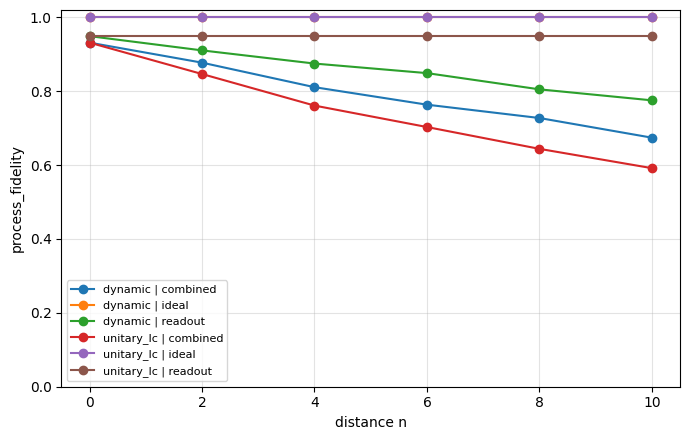

In [8]:
def plot_fidelity_vs_distance(results_df: pd.DataFrame, fidelity_col: str = "process_fidelity") -> None:
    if results_df.empty:
        print("No results to plot.")
        return
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for (implementation, noise_model), group in results_df.groupby(["implementation", "noise_model"]):
        group = group.sort_values("distance")
        ax.plot(group["distance"], group[fidelity_col], marker="o", label=f"{implementation} | {noise_model}")
    ax.set_xlabel("distance n")
    ax.set_ylabel(fidelity_col)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_fidelity_vs_distance(smoke_df, fidelity_col="process_fidelity")


## Pairwise noise-channel heatmaps

To identify the dominant limiting factor, we sweep two noise-channel intensities at a time and display `F_pro` as color. The third channel is held at zero.

The default grid uses five values per axis, at `distance = 6`, with both `unitary_Ic` and `dynamic`. That gives 25 points per heatmap, which is fine enough to see trends while still remaining practical for exact noisy simulation. The summary table compares the fidelity drop along each axis from the zero-noise corner.


unitary_Ic n=6 p_cnot=0 p_readout=0 -> F_pro=1.000 (1/25)


unitary_Ic n=6 p_cnot=0.0075 p_readout=0 -> F_pro=0.873 (2/25)
unitary_Ic n=6 p_cnot=0.015 p_readout=0 -> F_pro=0.758 (3/25)


unitary_Ic n=6 p_cnot=0.0225 p_readout=0 -> F_pro=0.660 (4/25)
unitary_Ic n=6 p_cnot=0.03 p_readout=0 -> F_pro=0.543 (5/25)
unitary_Ic n=6 p_cnot=0 p_readout=0.02 -> F_pro=0.945 (6/25)


unitary_Ic n=6 p_cnot=0.0075 p_readout=0.02 -> F_pro=0.832 (7/25)
unitary_Ic n=6 p_cnot=0.015 p_readout=0.02 -> F_pro=0.717 (8/25)


unitary_Ic n=6 p_cnot=0.0225 p_readout=0.02 -> F_pro=0.626 (9/25)


...

dynamic    n=6 p_readout=0 lambda_idle=0.015 -> F_pro=0.923 (21/25)


dynamic    n=6 p_readout=0.02 lambda_idle=0.015 -> F_pro=0.766 (22/25)


dynamic    n=6 p_readout=0.04 lambda_idle=0.015 -> F_pro=0.641 (23/25)


dynamic    n=6 p_readout=0.06 lambda_idle=0.015 -> F_pro=0.561 (24/25)


dynamic    n=6 p_readout=0.08 lambda_idle=0.015 -> F_pro=0.491 (25/25)


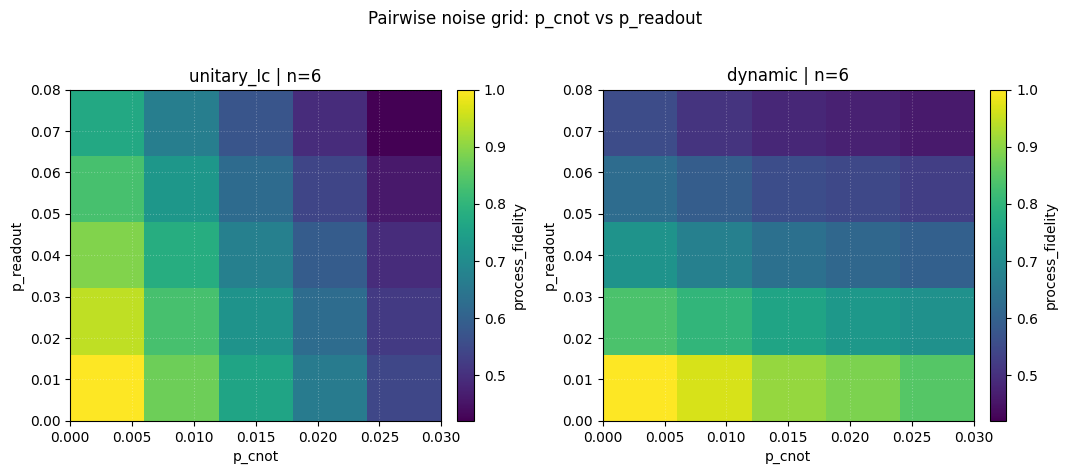

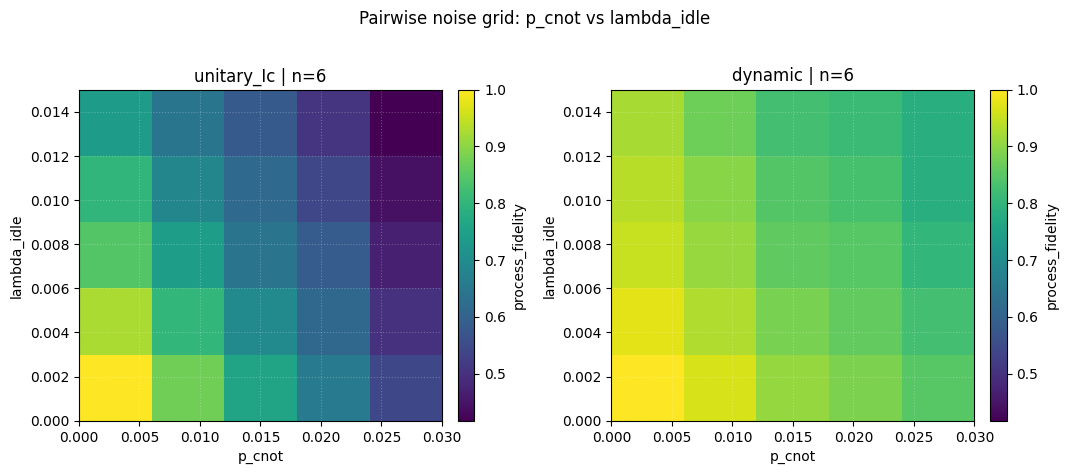

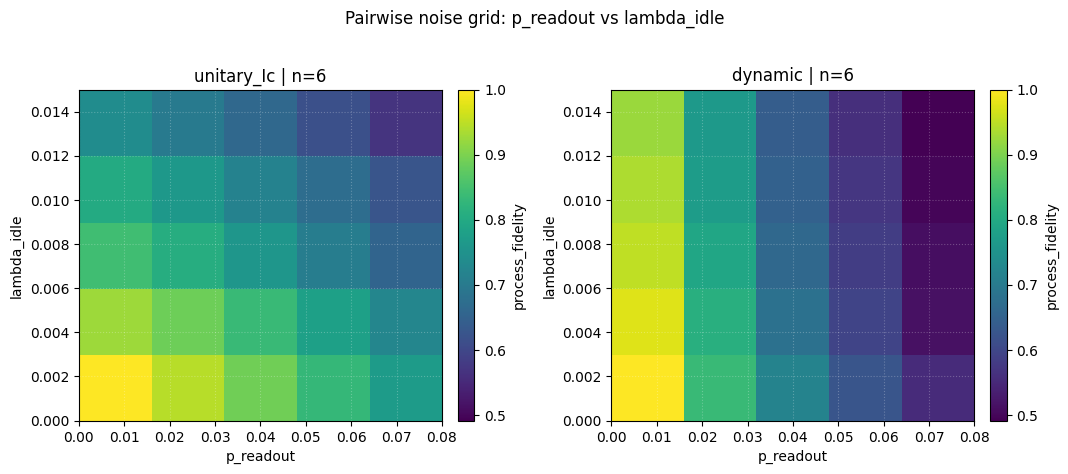

,implementation,distance,x_channel,y_channel,baseline_F_pro,x_only_F_pro,y_only_F_pro,both_max_F_pro,x_drop,y_drop,dominant_single_axis
0,unitary_Ic,6,p_cnot,p_readout,1.0,0.542969,0.770508,0.419922,0.457031,0.229492,p_cnot
1,dynamic,6,p_cnot,p_readout,1.0,0.847656,0.554688,0.460938,0.152344,0.445312,p_readout
2,unitary_Ic,6,p_cnot,lambda_idle,1.0,0.542969,0.738281,0.416992,0.457031,0.261719,p_cnot
3,dynamic,6,p_cnot,lambda_idle,1.0,0.847656,0.922852,0.782227,0.152344,0.077148,p_cnot
4,unitary_Ic,6,p_readout,lambda_idle,1.0,0.770508,0.738281,0.568359,0.229492,0.261719,lambda_idle
5,dynamic,6,p_readout,lambda_idle,1.0,0.554688,0.922852,0.491211,0.445312,0.077148,p_readout


In [9]:

def t2_from_lambda_idle(lambda_idle: float, t_cnot: float) -> float:
    lambda_idle = float(lambda_idle)
    if lambda_idle <= 0:
        return NOISE_CONFIGS["thermal"].t2
    if lambda_idle >= 1:
        raise ValueError("lambda_idle must be < 1")
    return -float(t_cnot) / math.log(1.0 - lambda_idle)


def make_two_channel_noise_config(
    x_channel: str,
    x_value: float,
    y_channel: str,
    y_value: float,
    base: NoiseConfig = NOISE_CONFIGS["combined"],
) -> NoiseConfig:
    values = {"p_cnot": 0.0, "p_readout": 0.0, "lambda_idle": 0.0}
    for channel, value in [(x_channel, x_value), (y_channel, y_value)]:
        if channel not in values:
            raise ValueError(f"unknown channel {channel!r}; use one of {sorted(values)}")
        values[channel] = float(value)

    p_cnot = values["p_cnot"]
    p_readout = values["p_readout"]
    lambda_idle = values["lambda_idle"]
    t2 = t2_from_lambda_idle(lambda_idle, base.t_cnot) if lambda_idle > 0 else base.t2
    t1 = max(base.t1, t2 / 2.0)

    return NoiseConfig(
        name=f"{x_channel}={x_value:.4g},{y_channel}={y_value:.4g}",
        p_1q=p_cnot / 10.0,
        p_cnot=p_cnot,
        p_readout=p_readout,
        t1=t1,
        t2=t2,
        t_1q=base.t_1q,
        t_cnot=base.t_cnot,
        t_measure=base.t_measure,
        include_depolarizing=p_cnot > 0,
        include_readout=p_readout > 0,
        include_thermal=lambda_idle > 0,
    )


def run_pairwise_noise_grid(
    distance: int,
    implementation: str,
    x_channel: str,
    x_values: np.ndarray,
    y_channel: str,
    y_values: np.ndarray,
    shots: int = 32,
    max_exact_noisy_qubits: int | None = MAX_EXACT_NOISY_QUBITS,
) -> pd.DataFrame:
    prepared = prepare_process_suite(implementation, distance)
    if max_exact_noisy_qubits is not None and prepared["base_circuit"].num_qubits > max_exact_noisy_qubits:
        raise ValueError(
            f"Refusing exact noisy simulation for {prepared['base_circuit'].num_qubits} qubits. "
            f"Set max_exact_noisy_qubits=None only after confirming the run cost."
        )

    rows = []
    total = len(x_values) * len(y_values)
    point = 0
    for y_value in y_values:
        for x_value in x_values:
            point += 1
            config = make_two_channel_noise_config(x_channel, x_value, y_channel, y_value)
            row = run_prepared_process_fidelity(prepared, noise_config=config, shots=shots)
            row.update(
                {
                    "x_channel": x_channel,
                    "y_channel": y_channel,
                    "x_value": float(x_value),
                    "y_value": float(y_value),
                }
            )
            rows.append(row)
            print(
                f"{implementation:10s} n={distance} {x_channel}={x_value:.4g} "
                f"{y_channel}={y_value:.4g} -> F_pro={row['process_fidelity']:.3f} ({point}/{total})"
            )
    return pd.DataFrame(rows)


def run_pairwise_noise_grids(
    distance: int,
    implementations: list[str],
    grid_specs: list[tuple[str, np.ndarray, str, np.ndarray]],
    shots: int = 32,
) -> pd.DataFrame:
    frames = []
    for x_channel, x_values, y_channel, y_values in grid_specs:
        for implementation in implementations:
            frames.append(
                run_pairwise_noise_grid(
                    distance=distance,
                    implementation=implementation,
                    x_channel=x_channel,
                    x_values=np.asarray(x_values, dtype=float),
                    y_channel=y_channel,
                    y_values=np.asarray(y_values, dtype=float),
                    shots=shots,
                )
            )
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_pairwise_heatmaps(pairwise_df: pd.DataFrame, fidelity_col: str = "process_fidelity") -> None:
    if pairwise_df.empty:
        print("No pairwise grid results to plot.")
        return

    for (x_channel, y_channel), pair_df in pairwise_df.groupby(["x_channel", "y_channel"], sort=False):
        implementations = list(pair_df["implementation"].drop_duplicates())
        fig, axes = plt.subplots(1, len(implementations), figsize=(5.4 * len(implementations), 4.6), squeeze=False)
        vmin = float(pair_df[fidelity_col].min())
        vmax = float(pair_df[fidelity_col].max())
        for ax, implementation in zip(axes[0], implementations):
            sub = pair_df[pair_df["implementation"] == implementation]
            pivot = sub.pivot(index="y_value", columns="x_value", values=fidelity_col).sort_index().sort_index(axis=1)
            im = ax.imshow(
                pivot.values,
                origin="lower",
                aspect="auto",
                extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
                vmin=vmin,
                vmax=vmax,
                cmap="viridis",
            )
            ax.set_title(f"{implementation} | n={int(sub['distance'].iloc[0])}")
            ax.set_xlabel(x_channel)
            ax.set_ylabel(y_channel)
            ax.grid(color="white", alpha=0.25, linestyle=":")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=fidelity_col)
        fig.suptitle(f"Pairwise noise grid: {x_channel} vs {y_channel}", y=1.02)
        plt.tight_layout()
        plt.show()


def summarize_pairwise_dominance(pairwise_df: pd.DataFrame, fidelity_col: str = "process_fidelity") -> pd.DataFrame:
    rows = []
    for keys, sub in pairwise_df.groupby(["implementation", "x_channel", "y_channel"], sort=False):
        implementation, x_channel, y_channel = keys
        x0 = float(sub["x_value"].min())
        y0 = float(sub["y_value"].min())
        xmax = float(sub["x_value"].max())
        ymax = float(sub["y_value"].max())

        def value_at(x, y):
            matched = sub[(np.isclose(sub["x_value"], x)) & (np.isclose(sub["y_value"], y))]
            return float(matched[fidelity_col].iloc[0]) if not matched.empty else np.nan

        baseline = value_at(x0, y0)
        x_only = value_at(xmax, y0)
        y_only = value_at(x0, ymax)
        both = value_at(xmax, ymax)
        x_drop = baseline - x_only
        y_drop = baseline - y_only
        rows.append(
            {
                "implementation": implementation,
                "distance": int(sub["distance"].iloc[0]),
                "x_channel": x_channel,
                "y_channel": y_channel,
                "baseline_F_pro": baseline,
                "x_only_F_pro": x_only,
                "y_only_F_pro": y_only,
                "both_max_F_pro": both,
                "x_drop": x_drop,
                "y_drop": y_drop,
                "dominant_single_axis": x_channel if x_drop > y_drop else y_channel,
            }
        )
    return pd.DataFrame(rows)


RUN_PAIRWISE_HEATMAPS = True
HEATMAP_DISTANCE = 6
HEATMAP_SHOTS = 32
PAIRWISE_GRID_POINTS = 5
P_CNOT_GRID = np.linspace(0.0, 0.03, PAIRWISE_GRID_POINTS)
P_READOUT_GRID = np.linspace(0.0, 0.08, PAIRWISE_GRID_POINTS)
LAMBDA_IDLE_GRID = np.linspace(0.0, 0.015, PAIRWISE_GRID_POINTS)

PAIRWISE_GRID_SPECS = [
    ("p_cnot", P_CNOT_GRID, "p_readout", P_READOUT_GRID),
    ("p_cnot", P_CNOT_GRID, "lambda_idle", LAMBDA_IDLE_GRID),
    ("p_readout", P_READOUT_GRID, "lambda_idle", LAMBDA_IDLE_GRID),
]

if RUN_PAIRWISE_HEATMAPS:
    pairwise_df = run_pairwise_noise_grids(
        distance=HEATMAP_DISTANCE,
        implementations=["unitary_Ic", "dynamic"],
        grid_specs=PAIRWISE_GRID_SPECS,
        shots=HEATMAP_SHOTS,
    )
    plot_pairwise_heatmaps(pairwise_df, fidelity_col="process_fidelity")
    dominance_df = summarize_pairwise_dominance(pairwise_df, fidelity_col="process_fidelity")
else:
    pairwise_df = pd.DataFrame()
    dominance_df = pd.DataFrame()

dominance_df


## Single-noise-source degradation vs distance

This experiment directly addresses the statement: analyze how each noise source degrades the teleported CNOT fidelity as `n` increases.

We run both implementations for every integer distance `n = 0, 1, ..., 14`, under exactly one active noise source at a time:

- `depolarizing`: one- and two-qubit depolarizing gate noise, including CNOT noise.
- `readout`: symmetric measurement bit-flip error on all measurements.
- `thermal`: `T1/T2` thermal relaxation during gate durations.

The result reports `F_pro` and derived `F_avg`. The exact Aer run is explicitly allowed up to `16` qubits because `n = 14` uses `n + 2 = 16` qubits.


n= 0 unitary_Ic depolarizing  F_pro=0.991 F_avg=0.993 lambda_tot=0.0100
n= 0 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 0 unitary_Ic thermal       F_pro=0.997 F_avg=0.997 lambda_tot=0.0000
n= 0 dynamic    depolarizing  F_pro=0.991 F_avg=0.993 lambda_tot=0.0100
n= 0 dynamic    readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 0 dynamic    thermal       F_pro=0.997 F_avg=0.997 lambda_tot=0.0150


n= 1 unitary_Ic depolarizing  F_pro=0.962 F_avg=0.970 lambda_tot=0.0500
n= 1 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 1 unitary_Ic thermal       F_pro=0.981 F_avg=0.985 lambda_tot=0.0000


n= 1 dynamic    depolarizing  F_pro=0.980 F_avg=0.984 lambda_tot=0.0200
n= 1 dynamic    readout       F_pro=0.926 F_avg=0.941 lambda_tot=0.0200


n= 1 dynamic    thermal       F_pro=0.989 F_avg=0.991 lambda_tot=0.0150
n= 2 unitary_Ic depolarizing  F_pro=0.930 F_avg=0.944 lambda_tot=0.0900
n= 2 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000
n= 2 unitary_Ic thermal       F_pro=0.970 F_avg=0.976 lambda_tot=0.0000


n= 2 dynamic    depolarizing  F_pro=0.966 F_avg=0.973 lambda_tot=0.0300
n= 2 dynamic    readout       F_pro=0.911 F_avg=0.929 lambda_tot=0.0400


...

n=14 unitary_Ic depolarizing  F_pro=0.645 F_avg=0.716 lambda_tot=0.5700
n=14 unitary_Ic readout       F_pro=0.949 F_avg=0.959 lambda_tot=0.0000


n=14 unitary_Ic thermal       F_pro=0.821 F_avg=0.857 lambda_tot=0.0000


n=14 dynamic    depolarizing  F_pro=0.882 F_avg=0.906 lambda_tot=0.1500


n=14 dynamic    readout       F_pro=0.718 F_avg=0.775 lambda_tot=0.2800


n=14 dynamic    thermal       F_pro=0.929 F_avg=0.943 lambda_tot=0.0150


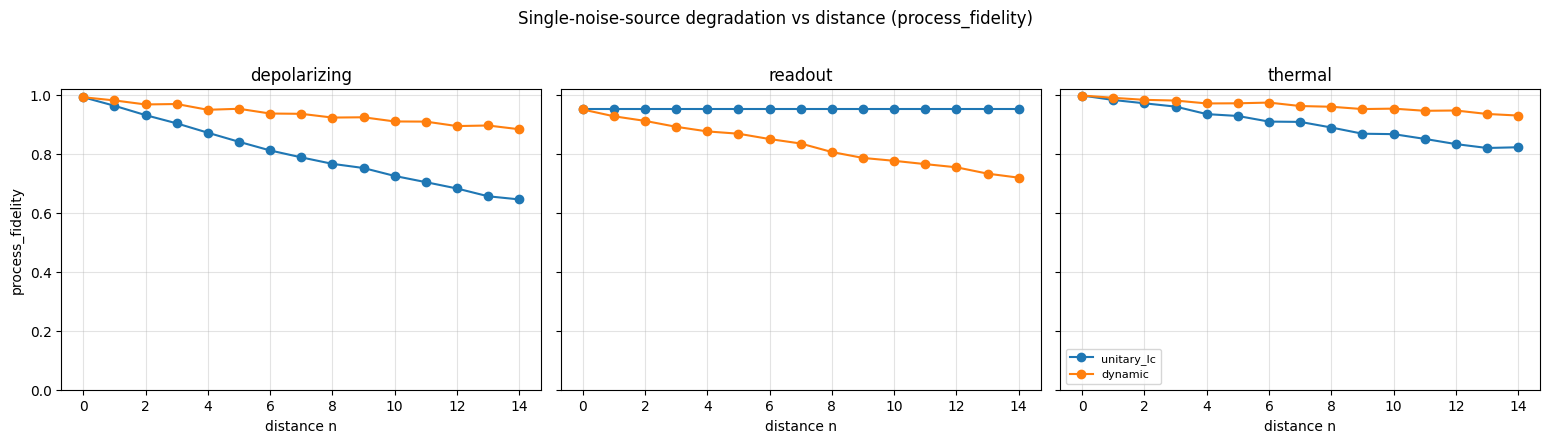

,noise_model,implementation,max_distance,F_pro_n0,F_pro_n14,total_drop,drop_per_n,lambda_tot_at_max_n,N_CNOT_at_max_n,N_mid_meas_at_max_n
0,depolarizing,unitary_Ic,14,0.990723,0.644531,0.346191,0.024728,0.570000,57,0
3,depolarizing,dynamic,14,0.990723,0.882324,0.108398,0.007743,0.150000,15,14
4,readout,dynamic,14,0.949219,0.718262,0.230957,0.016497,0.280000,15,14
1,readout,unitary_Ic,14,0.949219,0.949219,0.000000,0.000000,0.000000,57,0
2,thermal,unitary_Ic,14,0.996582,0.821289,0.175293,0.012521,0.000000,57,0
5,thermal,dynamic,14,0.996582,0.928711,0.067871,0.004848,0.014972,15,14


In [10]:

RUN_SINGLE_SOURCE_DISTANCE_EXPERIMENT = True

SOURCE_DEGRADATION_DISTANCES = list(range(0, 15))
SOURCE_DEGRADATION_NOISES = ["depolarizing", "readout", "thermal"]
SOURCE_DEGRADATION_IMPLEMENTATIONS = ["unitary_Ic", "dynamic"]
SOURCE_DEGRADATION_SHOTS = 64
SOURCE_DEGRADATION_MAX_QUBITS = 16


def run_single_source_distance_experiment() -> pd.DataFrame:
    return run_process_grid(
        distances=SOURCE_DEGRADATION_DISTANCES,
        implementations=SOURCE_DEGRADATION_IMPLEMENTATIONS,
        noise_labels=SOURCE_DEGRADATION_NOISES,
        shots=SOURCE_DEGRADATION_SHOTS,
        max_exact_noisy_qubits=SOURCE_DEGRADATION_MAX_QUBITS,
    )


def plot_single_source_distance_experiment(results_df: pd.DataFrame, fidelity_col: str = "process_fidelity") -> None:
    if results_df.empty:
        print("No single-source results to plot.")
        return
    noises = list(results_df["noise_model"].drop_duplicates())
    fig, axes = plt.subplots(1, len(noises), figsize=(5.2 * len(noises), 4.3), sharey=True)
    if len(noises) == 1:
        axes = [axes]
    for ax, noise_model in zip(axes, noises):
        sub = results_df[results_df["noise_model"] == noise_model]
        for implementation, group in sub.groupby("implementation", sort=False):
            group = group.sort_values("distance")
            ax.plot(group["distance"], group[fidelity_col], marker="o", label=implementation)
        ax.set_title(noise_model)
        ax.set_xlabel("distance n")
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.35)
    axes[0].set_ylabel(fidelity_col)
    axes[-1].legend(fontsize=8)
    fig.suptitle(f"Single-noise-source degradation vs distance ({fidelity_col})", y=1.02)
    plt.tight_layout()
    plt.show()


def summarize_single_source_degradation(results_df: pd.DataFrame, fidelity_col: str = "process_fidelity") -> pd.DataFrame:
    rows = []
    if results_df.empty:
        return pd.DataFrame()
    max_distance = int(results_df["distance"].max())
    for (noise_model, implementation), group in results_df.groupby(["noise_model", "implementation"], sort=False):
        group = group.sort_values("distance")
        f0 = float(group[group["distance"] == 0][fidelity_col].iloc[0])
        fmax = float(group[group["distance"] == max_distance][fidelity_col].iloc[0])
        rows.append(
            {
                "noise_model": noise_model,
                "implementation": implementation,
                "max_distance": max_distance,
                "F_pro_n0": f0,
                f"F_pro_n{max_distance}": fmax,
                "total_drop": f0 - fmax,
                "drop_per_n": (f0 - fmax) / max_distance if max_distance else 0.0,
                "lambda_tot_at_max_n": float(group[group["distance"] == max_distance]["lambda_tot"].iloc[0]),
                "N_CNOT_at_max_n": int(group[group["distance"] == max_distance]["N_CNOT"].iloc[0]),
                "N_mid_meas_at_max_n": int(group[group["distance"] == max_distance]["N_mid_meas"].iloc[0]),
            }
        )
    return pd.DataFrame(rows).sort_values(["noise_model", "total_drop"], ascending=[True, False])


if RUN_SINGLE_SOURCE_DISTANCE_EXPERIMENT:
    single_source_df = run_single_source_distance_experiment()
    plot_single_source_distance_experiment(single_source_df, fidelity_col="process_fidelity")
    single_source_summary_df = summarize_single_source_degradation(single_source_df, fidelity_col="process_fidelity")
else:
    single_source_df = pd.DataFrame()
    single_source_summary_df = pd.DataFrame()

single_source_summary_df


## Testing the paper lower bound

Appendix G states that, for a Pauli-Lindblad noise budget, the process fidelity is lower-bounded by

`F_pro >= exp(-lambda_tot)`.

The raw estimator in this notebook also includes final Pauli-certification readout noise. That final readout is not part of the teleported CNOT protocol budget, so the check below reports both the protocol bound and an estimator-aware bound that additionally accounts for final readout attenuation. It also reports baseline-normalized checks when a zero-distance or zero-noise baseline exists.

In [11]:

def depolarizing_pauli_lindblad_sum(p: float, num_qubits: int) -> float:
    """Appendix G: depolarizing q=1-p has equal Pauli rates with q=exp(-4**n lambda)."""
    p = float(p)
    if p <= 0.0:
        return 0.0
    if p >= 1.0:
        return math.inf
    dim_paulis = 4 ** int(num_qubits)
    return -((dim_paulis - 1.0) / dim_paulis) * math.log1p(-p)


def symmetric_bitflip_pauli_rate(p: float) -> float:
    """Rate lambda for flip probability p=(1-exp(-2 lambda))/2."""
    p = float(p)
    if p <= 0.0:
        return 0.0
    if p >= 0.5:
        return math.inf
    return -0.5 * math.log(1.0 - 2.0 * p)


def thermal_pauli_lindblad_sum_one_qubit(duration: float, t1: float, t2: float) -> float:
    """Appendix G twirled amplitude damping plus dephasing for one qubit over `duration`."""
    t2 = min(float(t2), 2.0 * float(t1))
    return float(duration) / (2.0 * float(t1)) + float(duration) / (2.0 * t2)


def noise_config_from_result_row(row: pd.Series) -> NoiseConfig | None:
    noise_model = row.get("noise_model")
    if isinstance(noise_model, str) and noise_model in NOISE_CONFIGS:
        return NOISE_CONFIGS[noise_model]
    if {"x_channel", "y_channel", "x_value", "y_value"}.issubset(row.index):
        if pd.notna(row["x_channel"]) and pd.notna(row["y_channel"]):
            return make_two_channel_noise_config(
                str(row["x_channel"]),
                float(row["x_value"]),
                str(row["y_channel"]),
                float(row["y_value"]),
            )
    return None


def pauli_lindblad_rates_for_bound(config: NoiseConfig) -> dict:
    """Rates matched to the simulator channels, expressed in the paper's additive lambda language."""
    lambda_idle = 0.0
    lambda_CNOT = 0.0
    lambda_meas = 0.0

    if config.include_depolarizing:
        lambda_CNOT += depolarizing_pauli_lindblad_sum(config.p_cnot, num_qubits=2)

    if config.include_thermal:
        one_qubit_cnot_time = thermal_pauli_lindblad_sum_one_qubit(config.t_cnot, config.t1, config.t2)
        lambda_idle += 2.0 * one_qubit_cnot_time
        lambda_CNOT += 2.0 * one_qubit_cnot_time

    if config.include_readout:
        lambda_meas += symmetric_bitflip_pauli_rate(config.p_readout)

    return {
        "lambda_idle_bound_rate": lambda_idle,
        "lambda_CNOT_bound_rate": lambda_CNOT,
        "lambda_meas_bound_rate": lambda_meas,
    }


def lower_bound_lambda_for_row(row: pd.Series) -> dict:
    config = noise_config_from_result_row(row)
    if config is None:
        return {
            "lambda_tot_protocol_bound": np.nan,
            "lambda_tot_estimator_bound": np.nan,
            "lambda_idle_bound_rate": np.nan,
            "lambda_CNOT_bound_rate": np.nan,
            "lambda_meas_bound_rate": np.nan,
            "N_final_process_meas_mean": np.nan,
        }

    rates = pauli_lindblad_rates_for_bound(config)
    t_idle = float(row.get("t_idle_cnot_units", 0.0) or 0.0)
    n_cnot = float(row.get("N_CNOT", 0.0) or 0.0)
    n_mid_meas = float(row.get("N_mid_meas", row.get("N_meas", 0.0)) or 0.0)
    n_process_meas_mean = float(row.get("N_process_meas_mean", n_mid_meas) or 0.0)
    n_final_meas_mean = max(0.0, n_process_meas_mean - n_mid_meas)

    lambda_protocol = (
        t_idle * rates["lambda_idle_bound_rate"]
        + n_cnot * rates["lambda_CNOT_bound_rate"]
        + n_mid_meas * rates["lambda_meas_bound_rate"]
    )

    # Final Pauli-readout flips attenuate measured expectations as exp(-2 lambda_meas per measured bit).
    lambda_estimator = lambda_protocol + 2.0 * n_final_meas_mean * rates["lambda_meas_bound_rate"]

    return {
        **rates,
        "lambda_tot_protocol_bound": lambda_protocol,
        "lambda_tot_estimator_bound": lambda_estimator,
        "N_final_process_meas_mean": n_final_meas_mean,
    }


def process_fidelity_se_upper_bound(shots_per_circuit: float) -> float:
    """Conservative standard-error scale for the 15 executed CNOT process Pauli terms."""
    shots = max(float(shots_per_circuit), 1.0)
    return math.sqrt(15.0 / (1024.0 * shots))


def collect_completed_experiment_frames() -> pd.DataFrame:
    frames = []
    for experiment_name, variable_name in [
        ("smoke", "smoke_df"),
        ("pairwise", "pairwise_df"),
        ("single_source", "single_source_df"),
        ("distance_sweep", "sweep_df"),
    ]:
        value = globals().get(variable_name)
        if isinstance(value, pd.DataFrame) and not value.empty:
            frame = value.copy()
            frame.insert(0, "experiment", experiment_name)
            frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def add_lower_bound_columns(results_df: pd.DataFrame, sigma: float = 3.0) -> pd.DataFrame:
    if results_df.empty:
        return results_df.copy()

    rows = []
    for _, row in results_df.iterrows():
        bound_info = lower_bound_lambda_for_row(row)
        rows.append(bound_info)
    bound_df = pd.concat([results_df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

    bound_df["F_protocol_lower_bound"] = np.exp(-bound_df["lambda_tot_protocol_bound"])
    bound_df["F_estimator_lower_bound"] = np.exp(-bound_df["lambda_tot_estimator_bound"])
    bound_df["F_pro_se_bound"] = bound_df["shots_per_circuit"].map(process_fidelity_se_upper_bound)
    bound_df["F_pro_tolerance"] = sigma * bound_df["F_pro_se_bound"]

    for label in ["protocol", "estimator"]:
        bound_col = f"F_{label}_lower_bound"
        margin_col = f"{label}_margin"
        pass_col = f"{label}_passes_with_tolerance"
        bound_df[margin_col] = bound_df["process_fidelity"] - bound_df[bound_col]
        bound_df[pass_col] = bound_df[margin_col] >= -bound_df["F_pro_tolerance"]

    bound_df["baseline_process_fidelity"] = np.nan
    bound_df["baseline_lambda_protocol_bound"] = np.nan
    bound_df["baseline_lambda_estimator_bound"] = np.nan

    for _, sub in bound_df.groupby(["experiment", "implementation", "noise_model"], dropna=False, sort=False):
        if "distance" not in sub.columns or not (sub["distance"] == 0).any():
            continue
        baseline = sub[sub["distance"] == 0].iloc[0]
        idx = sub.index
        bound_df.loc[idx, "baseline_process_fidelity"] = float(baseline["process_fidelity"])
        bound_df.loc[idx, "baseline_lambda_protocol_bound"] = float(baseline["lambda_tot_protocol_bound"])
        bound_df.loc[idx, "baseline_lambda_estimator_bound"] = float(baseline["lambda_tot_estimator_bound"])

    if {"x_channel", "y_channel", "x_value", "y_value"}.issubset(bound_df.columns):
        pairwise = bound_df[bound_df["experiment"] == "pairwise"]
        for _, sub in pairwise.groupby(["implementation", "distance", "x_channel", "y_channel"], dropna=False, sort=False):
            x0 = sub["x_value"].min()
            y0 = sub["y_value"].min()
            baseline_rows = sub[(np.isclose(sub["x_value"], x0)) & (np.isclose(sub["y_value"], y0))]
            if baseline_rows.empty:
                continue
            baseline = baseline_rows.iloc[0]
            idx = sub.index
            bound_df.loc[idx, "baseline_process_fidelity"] = float(baseline["process_fidelity"])
            bound_df.loc[idx, "baseline_lambda_protocol_bound"] = float(baseline["lambda_tot_protocol_bound"])
            bound_df.loc[idx, "baseline_lambda_estimator_bound"] = float(baseline["lambda_tot_estimator_bound"])

    has_baseline = bound_df["baseline_process_fidelity"].notna() & (bound_df["baseline_process_fidelity"] > 0)
    bound_df["relative_process_fidelity"] = np.nan
    bound_df.loc[has_baseline, "relative_process_fidelity"] = (
        bound_df.loc[has_baseline, "process_fidelity"] / bound_df.loc[has_baseline, "baseline_process_fidelity"]
    )

    for label in ["protocol", "estimator"]:
        lambda_col = f"lambda_tot_{label}_bound"
        baseline_lambda_col = f"baseline_lambda_{label}_bound"
        lower_col = f"relative_{label}_lower_bound"
        margin_col = f"relative_{label}_margin"
        pass_col = f"relative_{label}_passes_with_tolerance"
        bound_df[lower_col] = np.nan
        bound_df.loc[has_baseline, lower_col] = np.exp(
            -(bound_df.loc[has_baseline, lambda_col] - bound_df.loc[has_baseline, baseline_lambda_col])
        )
        bound_df[margin_col] = bound_df["relative_process_fidelity"] - bound_df[lower_col]

        relative_tolerance = np.full(len(bound_df), np.nan)
        for idx, row in bound_df[has_baseline].iterrows():
            f0 = float(row["baseline_process_fidelity"])
            f = float(row["process_fidelity"])
            se = float(row["F_pro_se_bound"])
            # Use the same conservative SE for the baseline unless the exact baseline row is looked up below.
            se0 = se
            relative_tolerance[idx] = sigma * math.sqrt((se / f0) ** 2 + ((f * se0) / (f0 ** 2)) ** 2)
        bound_df[f"relative_{label}_tolerance"] = relative_tolerance
        bound_df[pass_col] = bound_df[margin_col] >= -bound_df[f"relative_{label}_tolerance"]

    return bound_df


def summarize_lower_bound_checks(bound_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if bound_df.empty:
        return pd.DataFrame()
    checks = [
        ("raw_protocol", "process_fidelity", "F_protocol_lower_bound", "protocol_margin", "F_pro_tolerance", "protocol_passes_with_tolerance"),
        ("raw_estimator", "process_fidelity", "F_estimator_lower_bound", "estimator_margin", "F_pro_tolerance", "estimator_passes_with_tolerance"),
        ("relative_protocol", "relative_process_fidelity", "relative_protocol_lower_bound", "relative_protocol_margin", "relative_protocol_tolerance", "relative_protocol_passes_with_tolerance"),
        ("relative_estimator", "relative_process_fidelity", "relative_estimator_lower_bound", "relative_estimator_margin", "relative_estimator_tolerance", "relative_estimator_passes_with_tolerance"),
    ]
    for experiment, sub in bound_df.groupby("experiment", sort=False):
        for check_name, value_col, bound_col, margin_col, tol_col, pass_col in checks:
            valid = sub[value_col].notna() & sub[bound_col].notna() & sub[tol_col].notna()
            checked = sub[valid]
            if checked.empty:
                continue
            violation = checked[margin_col] < -checked[tol_col]
            rows.append(
                {
                    "experiment": experiment,
                    "check": check_name,
                    "rows_checked": int(len(checked)),
                    "violations_after_tolerance": int(violation.sum()),
                    "worst_margin": float(checked[margin_col].min()),
                    "worst_tolerance_adjusted_margin": float((checked[margin_col] + checked[tol_col]).min()),
                }
            )
    return pd.DataFrame(rows)


completed_experiments_df = collect_completed_experiment_frames()
lower_bound_check_df = add_lower_bound_columns(completed_experiments_df)
lower_bound_summary_df = summarize_lower_bound_checks(lower_bound_check_df)

violation_columns = [
    "experiment",
    "implementation",
    "distance",
    "noise_model",
    "process_fidelity",
    "F_protocol_lower_bound",
    "F_estimator_lower_bound",
    "relative_process_fidelity",
    "relative_protocol_lower_bound",
    "relative_estimator_lower_bound",
    "protocol_margin",
    "estimator_margin",
    "relative_protocol_margin",
    "relative_estimator_margin",
]

strict_violations_df = lower_bound_check_df[
    (~lower_bound_check_df["estimator_passes_with_tolerance"])
    | (
        lower_bound_check_df["relative_estimator_passes_with_tolerance"].notna()
        & (~lower_bound_check_df["relative_estimator_passes_with_tolerance"])
    )
][[col for col in violation_columns if col in lower_bound_check_df.columns]]

print(f"Collected {len(completed_experiments_df)} completed experiment rows.")
display(lower_bound_summary_df)
print("Estimator-aware violations after 3-sigma shot-noise tolerance:")
display(strict_violations_df.head(20))


Collected 276 completed experiment rows.


,experiment,check,rows_checked,violations_after_tolerance,worst_margin,worst_tolerance_adjusted_margin
0,smoke,raw_protocol,36,10,-0.052317,-0.006931
1,smoke,raw_estimator,36,0,0.000000,0.045387
2,smoke,relative_protocol,36,0,-0.001096,0.061604
3,smoke,relative_estimator,36,0,-0.001096,0.061604
4,pairwise,raw_protocol,150,18,-0.229492,-0.165306
5,pairwise,raw_estimator,150,0,0.000000,0.064186
6,pairwise,relative_protocol,150,14,-0.229492,-0.148463
7,pairwise,relative_estimator,150,0,0.000000,0.089333
8,single_source,raw_protocol,90,21,-0.053526,-0.008140
9,single_source,raw_estimator,90,0,-0.005821,0.039566


Estimator-aware violations after 3-sigma shot-noise tolerance:


,experiment,implementation,distance,noise_model,process_fidelity,F_protocol_lower_bound,F_estimator_lower_bound,relative_process_fidelity,relative_protocol_lower_bound,relative_estimator_lower_bound,protocol_margin,estimator_margin,relative_protocol_margin,relative_estimator_margin


## Next sweep template

Keep this disabled until we decide the distance range and shots. For larger distances, use the resource/error-budget table first, then selectively run exact noisy simulations where the qubit count is feasible.


In [12]:
RUN_DISTANCE_SWEEP = False

if RUN_DISTANCE_SWEEP:
    sweep_distances = [0, 1, 2, 4, 6, 8, 10]
    sweep_df = run_process_grid(
        distances=sweep_distances,
        implementations=["unitary_Ic", "dynamic"],
        noise_labels=["depolarizing", "readout", "thermal", "combined"],
        shots=256,
    )
    display(sweep_df)
    plot_fidelity_vs_distance(sweep_df, fidelity_col="process_fidelity")
else:
    print("Distance sweep disabled. Set RUN_DISTANCE_SWEEP = True after checking runtime.")


Distance sweep disabled. Set RUN_DISTANCE_SWEEP = True after checking runtime.
